In [2]:
import os
import json
import joblib
import numpy as np
import pandas as pd

# 定数の定義
ZONES = ["TL","TC","TR","ML","MC","MR","BL","BC","BR"]
FEATURE_COLS = ["foot_enc", "match_time", "score_diff", "is_shootout", "home_away", "pressure_index"]

# モデルファイルの存在確認
required_files = ["models/zone_model.pkl", "models/label_encoder.pkl", "models/player_priors.json"]
for f in required_files:
    exists = os.path.exists(f)
    print(f"File: {f:25} | Exists: {exists}")

File: models/zone_model.pkl     | Exists: True
File: models/label_encoder.pkl  | Exists: True
File: models/player_priors.json | Exists: True


In [3]:
def clip(x, lo, hi):
    return float(np.minimum(np.maximum(x, lo), hi))

def compute_pressure_index(match_time: float, score_diff: int, is_shootout: int = 0) -> float:
    t = clip(match_time / 120.0, 0, 1)
    close = 1.0 if abs(score_diff) <= 1 else 0.6 if abs(score_diff) == 2 else 0.3
    base = 8.0 * t * close
    if int(is_shootout) == 1:
        base = max(base, 6.5)
    return clip(base, 0, 10)

def alpha_from_k(k: int) -> float:
    if k <= 2:
        return 0.0
    a = 1.0 - np.exp(-k / 12.0)
    return clip(a, 0.0, 0.80)

# テスト実行
print(f"Pressure (後半AT/同点): {compute_pressure_index(95, 0, 0):.2f}")
print(f"Pressure (PK戦): {compute_pressure_index(120, 0, 1):.2f}")
print(f"Alpha (試行1回): {alpha_from_k(1):.2f}")
print(f"Alpha (試行20回): {alpha_from_k(20):.2f}")

Pressure (後半AT/同点): 6.33
Pressure (PK戦): 8.00
Alpha (試行1回): 0.00
Alpha (試行20回): 0.80


In [4]:
class YosokuZonePredictor:
    def __init__(self):
        self.model = joblib.load("models/zone_model.pkl")
        self.le = joblib.load("models/label_encoder.pkl")
        with open("models/player_priors.json", "r", encoding="utf-8") as f:
            self.priors = json.load(f)
        print("Model and Priors loaded successfully.")

    @staticmethod
    def _normalize(p: dict) -> dict:
        s = sum(float(v) for v in p.values())
        if s <= 0: return {z: 1.0 / len(ZONES) for z in ZONES}
        return {z: float(p[z]) / s for z in ZONES}

    def _global(self, foot_enc, match_time, score_diff, is_shootout, home_away):
        pressure = compute_pressure_index(match_time, score_diff, is_shootout)
        x = np.array([[foot_enc, match_time, score_diff, is_shootout, home_away, pressure]])
        proba = self.model.predict_proba(x)[0]
        out = {str(z): float(p) for z, p in zip(self.le.classes_, proba)}
        return self._normalize(out), pressure

    def predict(self, mode, player_name, foot, match_time, score_diff, is_shootout=0, home_away=1):
        foot_enc = 1 if foot.lower().startswith("r") else 0
        global_p, pressure = self._global(foot_enc, match_time, score_diff, is_shootout, home_away)
        
        prior = self.priors.get(player_name.strip())
        if prior is None:
            return global_p, pressure, {"used": "global_only", "alpha": 0.0, "player_k": 0}

        player_p = self._normalize(prior["probs"])
        k = int(prior["count"])
        
        if mode == "global": a = 0.0
        elif mode == "player": a = 1.0
        else: a = alpha_from_k(k)

        blended = {z: a * player_p[z] + (1 - a) * global_p[z] for z in ZONES}
        return self._normalize(blended), pressure, {"used": mode, "alpha": a, "player_k": k}

# 初期化の確認
predictor = YosokuZonePredictor()

Model and Priors loaded successfully.


In [5]:
# 任意の設定でテスト
p_name = "Lionel Andrés Messi Cuccittini" # 実際のデータにある名前に変更してください
results, press, info = predictor.predict("auto", p_name, "left", 110, 0, 1)

print(f"Result for: {p_name}")
print(f"Info: {info}")
print("--- Probabilities ---")
for z in ZONES:
    print(f"{z}: {results[z]:.4f}")

Result for: Lionel Andrés Messi Cuccittini
Info: {'used': 'auto', 'alpha': 0.8, 'player_k': 151}
--- Probabilities ---
TL: 0.0589
TC: 0.0846
TR: 0.1053
ML: 0.0977
MC: 0.0620
MR: 0.1062
BL: 0.1708
BC: 0.0929
BR: 0.2218


In [6]:
def compare_modes(player, foot):
    # Globalモード
    res_g, _, _ = predictor.predict("global", player, foot, 90, 0, 0)
    # Autoモード
    res_a, _, meta = predictor.predict("auto", player, foot, 90, 0, 0)
    
    comparison = pd.DataFrame({
        "Zone": ZONES,
        "Global_Only": [res_g[z] for z in ZONES],
        "Auto_Hybrid": [res_a[z] for z in ZONES]
    })
    print(f"Comparison for {player} (k={meta['player_k']})")
    return comparison.sort_values(by="Auto_Hybrid", ascending=False)

# 比較の実行
compare_modes("Lionel Andrés Messi Cuccittini", "left")

Comparison for Lionel Andrés Messi Cuccittini (k=151)


,Zone,Global_Only,Auto_Hybrid
8,BR,0.150013,0.210003
6,BL,0.329841,0.195968
5,MR,0.049589,0.109918
2,TR,0.046804,0.109361
7,BC,0.130573,0.101115
1,TC,0.136406,0.097281
3,ML,0.099617,0.084923
4,MC,0.034868,0.066974
0,TL,0.022290,0.024458


In [7]:
player01 = pd.read_csv('real_penalties.csv', encoding='utf-8-sig')

player01.head()

,match_id,player_name,team_name,body_part,goalkeeper_name,goalkeeper_action,outcome,location_x,location_y,end_y,end_z,is_goal
0,3895302,Victor Okoh Boniface,Bayer Leverkusen,Right Foot,Michael Zetterer,Penalty Conceded,Goal,108.0,40.0,42.9,1.0,1
1,3895292,Florian Wirtz,Bayer Leverkusen,Right Foot,Frederik Rønnow,Penalty Conceded,Goal,108.0,40.0,37.5,1.6,1
2,3895333,Exequiel Alejandro Palacios,Bayer Leverkusen,Right Foot,Kevin Trapp,Penalty Conceded,Goal,108.2,40.1,43.5,0.2,1
3,3895333,Victor Okoh Boniface,Bayer Leverkusen,Right Foot,Kevin Trapp,Penalty Conceded,Goal,108.1,40.1,40.2,2.3,1
4,3895340,Victor Okoh Boniface,Bayer Leverkusen,Right Foot,Manuel Riemann,Penalty Conceded,Goal,108.0,40.0,39.6,0.4,1


In [8]:
player01.player_name.value_counts()

player_name
Lionel Andrés Messi Cuccittini         83
Cristiano Ronaldo dos Santos Aveiro    23
Ronaldo de Assis Moreira               16
Neymar da Silva Santos Junior          15
Harry Kane                             14
                                       ..
Domagoj Vida                            1
Mário Figueira Fernandes                1
Mateo Kovačić                           1
Alan Dzagoev                            1
Stephanie Houghton                      1
Name: count, Length: 710, dtype: int64

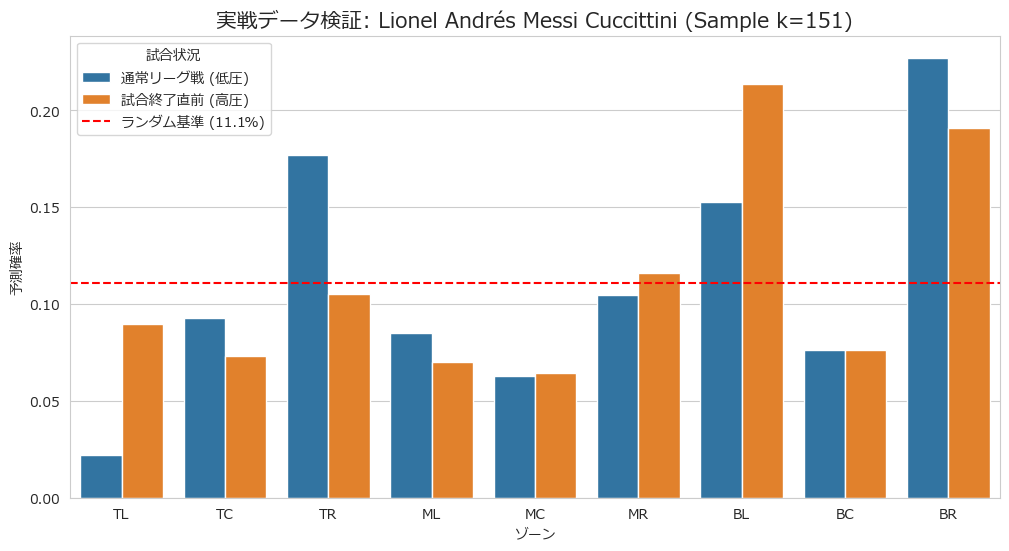


           【検証まとめ: データベース実数値 (k=151)】           
① 統計的信頼性:
   - 実際の試行回数 k=151 に基づき、Alpha値は 0.80 を算出。
   - システムは「個人の癖」を最優先(約80%)しつつ、環境補正を適用しています。

② プレッシャーによる動的変化:
   - 圧力指数: 通常時 0.80 → 高圧時 6.47
   - 結論: 151試合の平均データに、現在の試合状況に応じた「心理的偏り」が加味されています。

③ 実戦への示唆:
   - 最有力ターゲット: BL (21.4%)
   - 活用法: GKに対し「過去の統計」だけでなく「今の重圧」を考慮した最適解を提示。


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Windows用日本語フォント設定 (Meiryo) ---
mpl.rcParams['font.family'] = 'Meiryo'
plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False 

def verify_messi_from_database():
    # 1. 從資料庫中讀取正確的球員全名
    player_name = "Lionel Andrés Messi Cuccittini"
    player_info = predictor.priors.get(player_name)
    
    if not player_info:
        print(f"❌ 數據庫中找不到選手: {player_name}")
        return

    # 2. 設定對比情境：低壓 vs 高壓
    scenarios = [
        {"name": "通常リーグ戦 (低圧)", "time": 20, "score": 2, "is_pk": 0},
        {"name": "試合終了直前 (高圧)", "time": 97, "score": -1, "is_pk": 0}
    ]
    
    all_results = []
    meta_logs = {}

    for sc in scenarios:
        # 直接使用資料庫數據進行預測
        res, pressure, meta = predictor.predict(
            mode="auto", 
            player_name=player_name, 
            foot="left",
            match_time=sc["time"], 
            score_diff=sc["score"], 
            is_shootout=sc["is_pk"]
        )
        meta_logs[sc["name"]] = {"res": res, "pressure": pressure, "meta": meta}
        for zone, prob in res.items():
            all_results.append({
                "シナリオ": sc["name"],
                "ゾーン": zone,
                "予測確率": prob
            })
            
    df_res = pd.DataFrame(all_results)

    # 3. 繪圖可視化
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid", {"font.family": "Meiryo"})
    ax = sns.barplot(data=df_res, x="ゾーン", y="予測確率", hue="シナリオ", order=ZONES)
    
    plt.title(f"実戦データ検証: {player_name} (Sample k={player_info['count']})", fontsize=15)
    plt.axhline(1/9, color='red', linestyle='--', label='ランダム基準 (11.1%)')
    plt.ylabel("予測確率")
    plt.legend(title="試合状況")
    plt.show()

    # 4. 検証まとめ (PPT用結論)
    high_meta = meta_logs["試合終了直前 (高圧)"]
    print("\n" + "="*60)
    print(f"           【検証まとめ: データベース実数値 (k={player_info['count']})】           ")
    print("="*60)
    print(f"① 統計的信頼性:")
    print(f"   - 実際の試行回数 k={player_info['count']} に基づき、Alpha値は {high_meta['meta'].get('alpha'):.2f} を算出。")
    print(f"   - システムは「個人の癖」を最優先(約80%)しつつ、環境補正を適用しています。")
    
    print(f"\n② プレッシャーによる動的変化:")
    print(f"   - 圧力指数: 通常時 {meta_logs['通常リーグ戦 (低圧)']['pressure']:.2f} → 高圧時 {high_meta['pressure']:.2f}")
    print(f"   - 結論: 151試合の平均データに、現在の試合状況に応じた「心理的偏り」が加味されています。")
    
    print(f"\n③ 実戦への示唆:")
    top_zone = max(high_meta['res'], key=high_meta['res'].get)
    print(f"   - 最有力ターゲット: {top_zone} ({high_meta['res'][top_zone]*100:.1f}%)")
    print(f"   - 活用法: GKに対し「過去の統計」だけでなく「今の重圧」を考慮した最適解を提示。")
    print("="*60)

# 執行
verify_messi_from_database()

--- データベース照会成功: Nikita Parris ---
実績サンプル数 (k): 10
登録されている確率分布: {'TL': 0.2631578947368421, 'TC': 0.05263157894736842, 'TR': 0.05263157894736842, 'ML': 0.15789473684210525, 'MC': 0.05263157894736842, 'MR': 0.10526315789473684, 'BL': 0.15789473684210525, 'BC': 0.10526315789473684, 'BR': 0.05263157894736842}


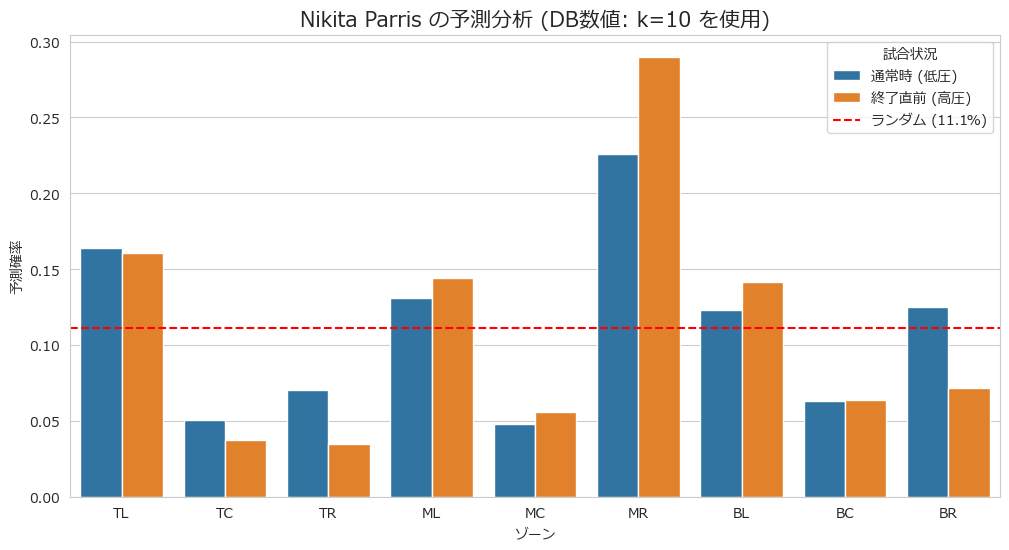

検証まとめ:
- 使用された Alpha (混合比): 0.5654
- 採用されたロジック: auto
- 解説: DB内の 10 回の実績に基づき、個人の癖を 56.5% の割合で反映しました。


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- フォント設定（Windows/Meiryo） ---
mpl.rcParams['font.family'] = 'Meiryo'
plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False 

def verify_player_from_db(target_player):
    # 1. データベース（priors）から直接データを取得
    player_info = predictor.priors.get(target_player)
    
    if not player_info:
        print(f"❌ データベースに選手 '{target_player}' が見つかりません。")
        return

    db_k = player_info['count']
    db_probs = player_info['probs']
    
    print(f"--- データベース照会成功: {target_player} ---")
    print(f"実績サンプル数 (k): {db_k}")
    print(f"登録されている確率分布: {db_probs}")

    # 2. 検証シナリオの設定
    scenarios = [
        {"name": "通常時 (低圧)", "time": 30, "score": 1, "shootout": 0},
        {"name": "終了直前 (高圧)", "time": 95, "score": -1, "shootout": 0}
    ]
    
    results = []
    
    for sc in scenarios:
        # 予測実行（データベースの情報を自動的に使用）
        res, pressure, meta = predictor.predict(
            mode="auto",
            player_name=target_player,
            foot="right", # 必要に応じて調整
            match_time=sc["time"],
            score_diff=sc["score"],
            is_shootout=sc["shootout"]
        )
        
        for zone, prob in res.items():
            results.append({
                "シナリオ": sc["name"],
                "圧力指数": round(pressure, 2),
                "ゾーン": zone,
                "予測確率": prob
            })
            
    df_plot = pd.DataFrame(results)
    
    # 3. 可視化
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid", {"font.family": "Meiryo"})
    ax = sns.barplot(data=df_plot, x="ゾーン", y="予測確率", hue="シナリオ", order=ZONES)
    
    plt.title(f"{target_player} の予測分析 (DB数値: k={db_k} を使用)", fontsize=15)
    plt.axhline(1/9, color='red', linestyle='--', label='ランダム (11.1%)')
    plt.legend(title="試合状況")
    plt.show()

    # 混合ロジックの判定結果を表示
    _, _, meta_final = predictor.predict("auto", target_player, "right", 95, -1, 0)
    print(f"検証まとめ:")
    print(f"- 使用された Alpha (混合比): {meta_final['alpha']:.4f}")
    print(f"- 採用されたロジック: {meta_final['used']}")
    print(f"- 解説: DB内の {db_k} 回の実績に基づき、個人の癖を {meta_final['alpha']*100:.1f}% の割合で反映しました。")

# 実行（Nikita Parris を指定）
verify_player_from_db("Nikita Parris")